# Assignment 2

In [1]:
import numpy as np
from scipy.special import softmax

## Problem 1

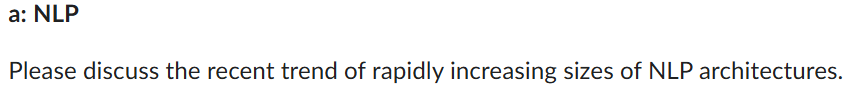

The recent trends in Natural Language Processing (NLP) have changed the way we use the computer. Chatbots are getting more and more popular, and we (users) expect them to only get better. To improve the chatbot, it comes with a cost of size. The network is becoming larger, and this might be a problem. At the moment (DEC2023) a chatgpt query cost 3Wh which translates to 36 cents, according to Medium. This is around 10 times more than a google search. Chatgpt alone consumes 0.5 million KWh pr day. In 2024, where minimizing power consumption is a huge deal, we need to consider how much better the NLP gets, when the increases in size and therefore consume more power.

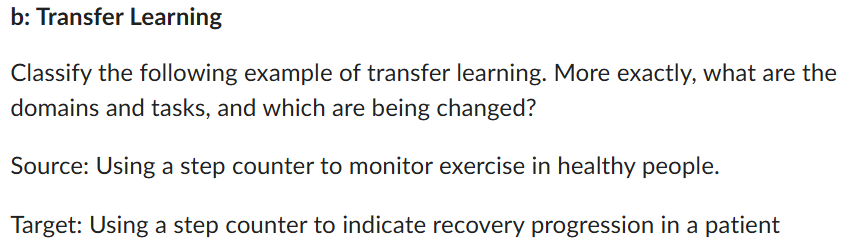

When talking about transfer learning, we often use the use the terminology of domain and task, and source and target. 

In this case where we want to use a step counter for two different purposes, we can say that the domain is the same $D_S=D_T$, since we use a step counter in both scenarios, but the tasks are different. 

This is an example of inductive transfer learning.

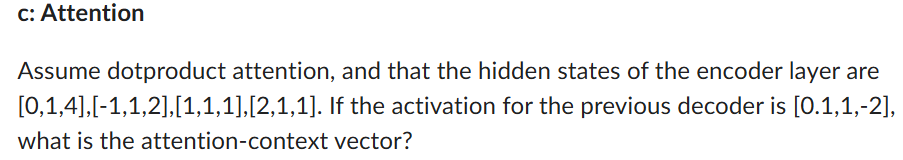

In [2]:
# Encoder hidden states
encoder_hidden_states = np.array([
    [0, 1, 4],
    [-1, 1, 2],
    [1, 1, 1],
    [2, 1, 1]
])

# Decoder activation (s_(i-1))
decoder_activation = np.array([0.1, 1, -2])

# Step 1: Calculate attention scores using dot product (a_ij = s_(i-1)^T * h_j)
scores = np.dot(encoder_hidden_states, decoder_activation)
print(f"a_ij = {scores}")

# Step 2: Apply softmax to get attention weights (alpha_ij = softmax(a_ij))
attention_weights = softmax(scores)
print(f"alpha_ij = {attention_weights}")

# Step 3: Calculate attention-context vector as weighted sum of encoder hidden states (c_i = sum(alpha_ij * h_j))
attention_context_vector = np.sum(attention_weights[:, np.newaxis] * encoder_hidden_states, axis=0)
print(f"c_i = {attention_context_vector}")

a_ij = [-7.  -3.1 -0.9 -0.8]
alpha_ij = [0.00101111 0.04995145 0.45081253 0.4982249 ]
c_i = [1.39731088 1.         1.05298479]


The attention context vector is approx: $c_i = [1.4, 1, 1.05]$

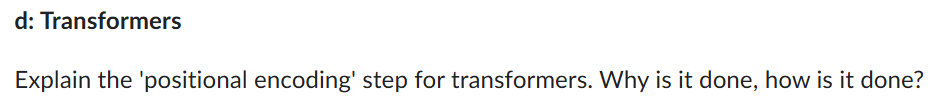

Positional encoding is an important step in transformer models, which are used in natural language processing tasks.

Transformers do not have a built-in sense of the order of the input tokens because they process the input sequence in parallel rather than sequentially. Becuase of this, positional encoding is introduced. The positional encoding provides the order information, allowing the model to understand and remember the order of the tokens.

Positional encoding involves adding a set of vectors to the inputs, where each vector represents the position of a token in the sequence. These vectors are designed to encode positional information in a way that the model can learn to interpret.

A common method for generating positional encodings is using sine and cosine functions of different frequencies.

$$
\begin{aligned}
PE(pos,2i) &= sin(\frac{pos}{10000^{\frac{2i}{d_{model}}}}) \\
PE(pos,2i+1) &= cos(\frac{pos}{10000^{\frac{2i}{d_{model}}}})
\end{aligned}
$$

Where pos is the position in the sequence and i is the dimensions index.

The input to the transformer becomes:
$$
X \rightarrow X + PE
$$

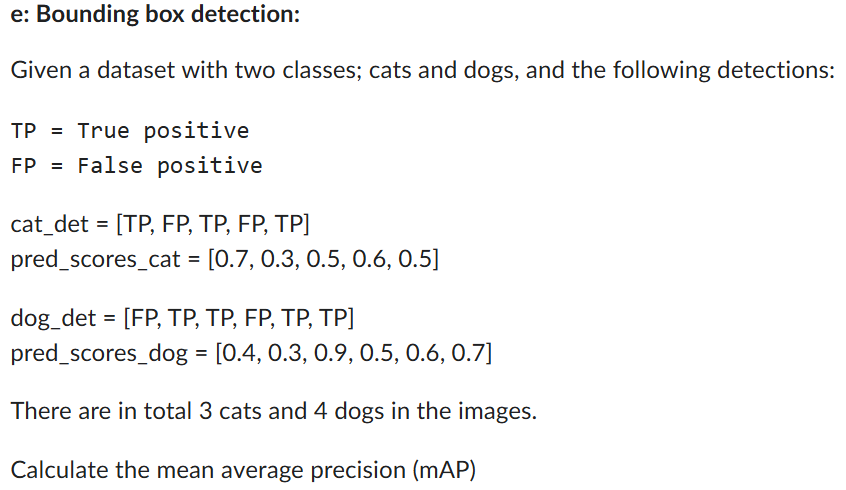

We use the procedure from slides and the formula from slides:

- First we sort by pred_score
- Then we calulate precision and recall
- Then we calculate the average precision with the formula: 
$$AP=\sum_{n-1} {(R_{n+1}-R_{n})P(R_{n+1})}$$

- The mean average is then the mean between the two average precisions

In [3]:
# Given data
cat_det = ['TP', 'FP', 'TP', 'FP', 'TP']
pred_scores_cat = [0.7, 0.3, 0.5, 0.6, 0.5]
dog_det = ['FP', 'TP', 'TP', 'FP', 'TP', 'TP']
pred_scores_dog = [0.4, 0.3, 0.9, 0.5, 0.6, 0.7]

def precision_recall(detection, prediction):
    # Sort the predictions by decreasing score
    sorted_indices = np.argsort(prediction)[::-1]
    detection = np.array(detection)[sorted_indices]
    
    # Calculate precision and recall
    tp = np.cumsum(detection == 'TP')
    fp = np.cumsum(detection == 'FP')
    # Count the number of true positives
    len_true = np.sum(detection == 'TP')
    # Calculate precision and recall
    precision = tp / (tp + fp)
    recall = tp / len_true
    # Calculate average precision
    ap = 0
    for i in range(len(recall) - 1):
        ap += (recall[i+1] - recall[i]) * precision[i+1]
    return precision, recall, ap

# Calculate precision, recall and average precision for cat detections
precision_cat, recall_cat, ap_cat = precision_recall(cat_det, pred_scores_cat)
print(f"Precision cat: {precision_cat}")
print(f"Recall cat: {recall_cat}")
print(f"Average Precision cat: {np.round(ap_cat,2)}")

# Calculate precision, recall and average precision for dog detections
precision_dog, recall_dog, ap_dog = precision_recall(dog_det, pred_scores_dog)
print(f"Precision dog: {precision_dog}")
print(f"Recall dog: {recall_dog}")
print(f"Average Precision dog: {np.round(ap_dog,2)}")

# Calculate mean average precision
map = (ap_cat + ap_dog) / 2
print(f"Mean Average Precision: {np.round(map,2)}")

Precision cat: [1.         0.5        0.66666667 0.75       0.6       ]
Recall cat: [0.33333333 0.33333333 0.66666667 1.         1.        ]
Average Precision cat: 0.47
Precision dog: [1.         1.         1.         0.75       0.6        0.66666667]
Recall dog: [0.25 0.5  0.75 0.75 0.75 1.  ]
Average Precision dog: 0.67
Mean Average Precision: 0.57


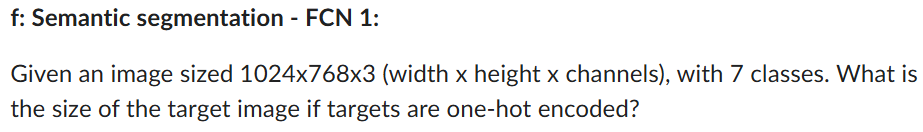

In semantic segmentation, each pixel needs to be classified. After this segmantation, we are able to create an 1024x768x1 image with the most probable classes for each pixel. 

Since each pixel has a probability to belong in each of the 7 classes, the target needs to be 1024x768xclasses = 1024x768x7.


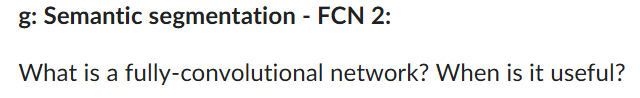

Like the name states, a fully-convolutional network (FCN) is a neural network that consists of only convolutional layers. This type of network is commonly used in computer vision tasks, such as image segmentation, where the input and output are images. 

The is usefull when you want to classify each pixel of an image. This is usefull for many applications, where you want to divide your image into multible segments. Eg. dividing a picture into its core components

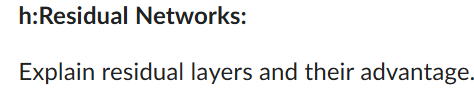

Residual layers are fundamental components of Residual Networks (ResNets), which are designed to address the vanishing gradient problem, making it easier to train very deep neural networks. These layers incorporate skip connections that add the input directly to the output, facilitating better gradient flow. This approach not only mitigates the vanishing gradient issue but also enables faster convergence during training, leading to higher accuracy on various tasks.




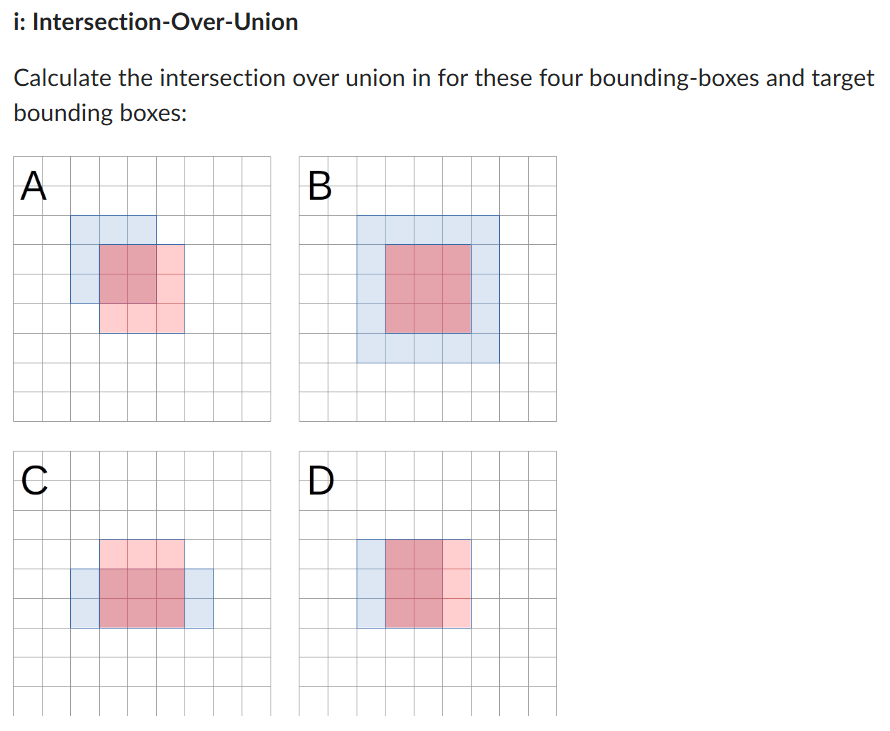

Intersection over Union (IoU) is measure of how good a bounding box fits an object

The formula for IoU is given by:
$$
IOU = \frac{\text{Area of Intersection of two boxes}}{\text{Area of Union of two boxes}}
$$

Using this formula we can calculate the IoU of two boxes.

$$
\begin{aligned}
IoU_A &= \frac{4}{2\cdot 9 - 4} = \frac{4}{14} = \frac{2}{7}\\

IoU_B &= \frac{9}{5 \cdot 5} = \frac{9}{25}\\

IoU_C &= \frac{6}{10+3} = \frac{6}{13} \\

IoU_D &= \frac{6}{2\cdot6} = \frac{6}{12} = \frac{1}{2} \\
\end{aligned}
$$

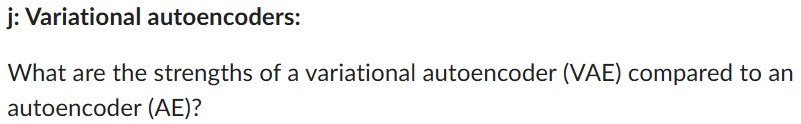

Both VAE and AE are encoders used for data compression and feature extraction. They work somehow quite different. The main difference between the two encoders lies in the regularization of the latant space, where the compressed data is stored. VAEs regularize the latant space, AE does not. This has the advantage that 

## Problem 2

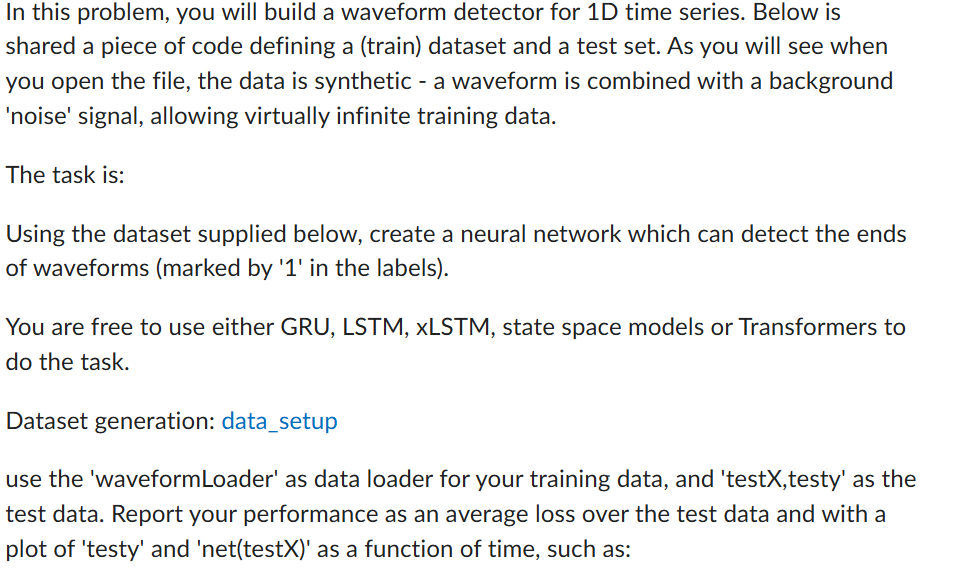
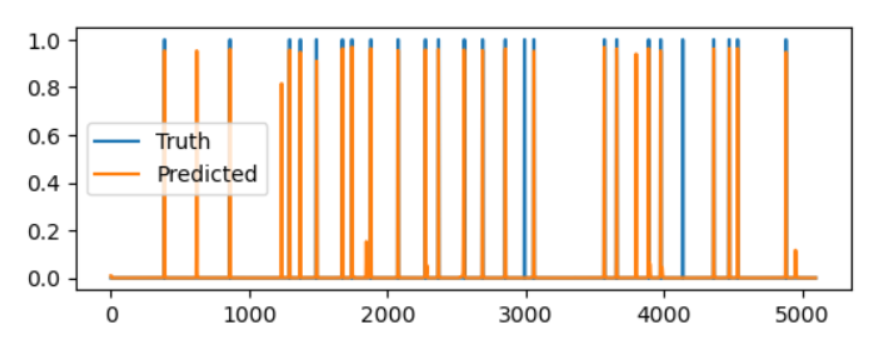

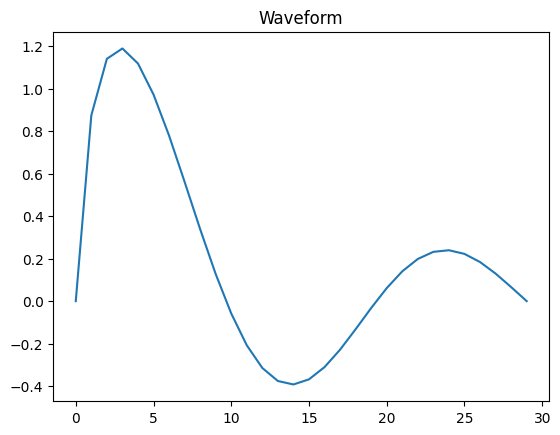

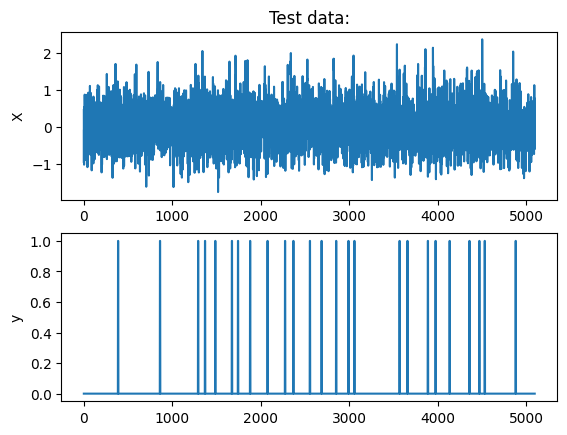

In [4]:
#%% load packages

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

#%%

#Prepare waveform data set container:
class waveFormDataset(torch.utils.data.Dataset):
    """waveFormDetectionDataset"""

    def __init__(self, waveforms, backgroundGenerator, targetRate=1):
        """
        Args:
            waveforms: array of size nxl, showing n different examples of target waveforms, length l
            backgroundGenerator: function, no input, outputs non-target signals, length L>l
        """

        if len(waveforms.shape)==0:
            waveforms=np.expand_dims(waveforms,0)

        self.ntargets=waveforms.shape[0]
        self.targets=waveforms
        self.backgroundGenerator=backgroundGenerator
        self.targetRate=targetRate

    def __len__(self):
        return 1000 #arbitrary

    def __getitem__(self, idx):
        #combines targets and backgroundGenerator. includes target in targetRate*100 percentage of outputs

        sample=self.backgroundGenerator()

        assert(len(sample)>=self.targets.shape[1])

        labels=sample*0

        if np.random.rand()<=self.targetRate:
            target=self.targets[np.random.randint(0,self.ntargets),:]
            target=torch.reshape(target,(-1,1))
            targetL=len(target)

            backgroundL=len(sample)

            endBuffer=4 #we need to ensure a bit of space at the end for placing 1-labels
            startIdx=np.random.randint(0,backgroundL-targetL-endBuffer,1)[0]
            sample[startIdx:(startIdx+targetL)]=sample[startIdx:(startIdx+targetL)]+target
            labels[startIdx+targetL+range(0,endBuffer)]=1


        return sample,labels

# %%

# setup dataset

#training:
targetL=30
waveform=np.sin(np.linspace(0,np.pi*3,targetL))/np.linspace(.2,5,targetL)
waveform=np.expand_dims(waveform,0)
waveform=torch.tensor(waveform,dtype=torch.float32)

def bgg():
    backgroundL=100
    scale=.5
    background=torch.tensor(np.random.normal(0,scale=scale,size=(backgroundL,1)),dtype=torch.float32)
    return background

wfDataset=waveFormDataset(waveform,bgg,.5)
e=wfDataset.__getitem__(1)
waveformLoader=torch.utils.data.DataLoader(wfDataset,batch_size=32)
# %%

#seed random number generator:
torch.manual_seed(1066)
np.random.seed(1066)

#test dataset:
nTest=50
testX,testy=wfDataset.__getitem__(1)

for iVal in range(nTest):
    x,y=wfDataset.__getitem__(1)
    testX=torch.cat((testX,x),0)
    testy=torch.cat((testy,y),0)


testX=torch.unsqueeze(testX,0)

plt.plot(waveform[0,:])
plt.title('Waveform')
plt.figure()
plt.subplot(2,1,1)
plt.plot(testX[0,:])
plt.ylabel('X')
plt.title('Test data:')

plt.subplot(2,1,2)
plt.plot(testy[:,0])
plt.ylabel('y')
plt.show()

In [ ]:
# Using LSTM to detect waveforms
class WaveformDetector(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1, output_size=1):
        super(WaveformDetector, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        #LSTM layer
        out, _ = self.lstm(x)
        #Linear layer
        out = self.linear(out)
        return out
    
# Create the model
model = WaveformDetector()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Use Adam optimizer starting rather high with lr=0.01
schedular = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9) # Reduce learning rate by 10% every 10 epochs to make up for high starting learning rate
# %% Training Loop
num_epochs = 250
loss_list = [] # Store loss values for plotting
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for samples, labels in waveformLoader:
        # Ensure `samples` has shape (batch_size, sequence_length, input_size=1)
        samples = samples.view(samples.size(0), samples.size(1), -1)  # Reshape to 3D

        # Ensure `labels` has shape (batch_size, sequence_length, output_size=1)
        labels = labels.view(labels.size(0), labels.size(1), -1)  # Reshape to 3D

        # Forward pass
        outputs = model(samples)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Reduce learning rate
    schedular.step()
    # Calculate average loss over all batches
    avg_loss = running_loss / len(waveformLoader)
    # Store loss for plotting
    loss_list.append(avg_loss)
    #Only print every 10 epochs
    if epoch % 25 == 24:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

# Test the model
model.eval()
with torch.no_grad():
    testX = testX.view(testX.size(0), testX.size(1), -1)  # Reshape to 3D

    predictions = model(testX)
    predictions = predictions.squeeze().numpy()  # Convert predictions to numpy for plotting

Epoch [25/250], Loss: 0.0060
Epoch [50/250], Loss: 0.0035
Epoch [75/250], Loss: 0.0035
Epoch [100/250], Loss: 0.0036
Epoch [125/250], Loss: 0.0033
Epoch [150/250], Loss: 0.0029


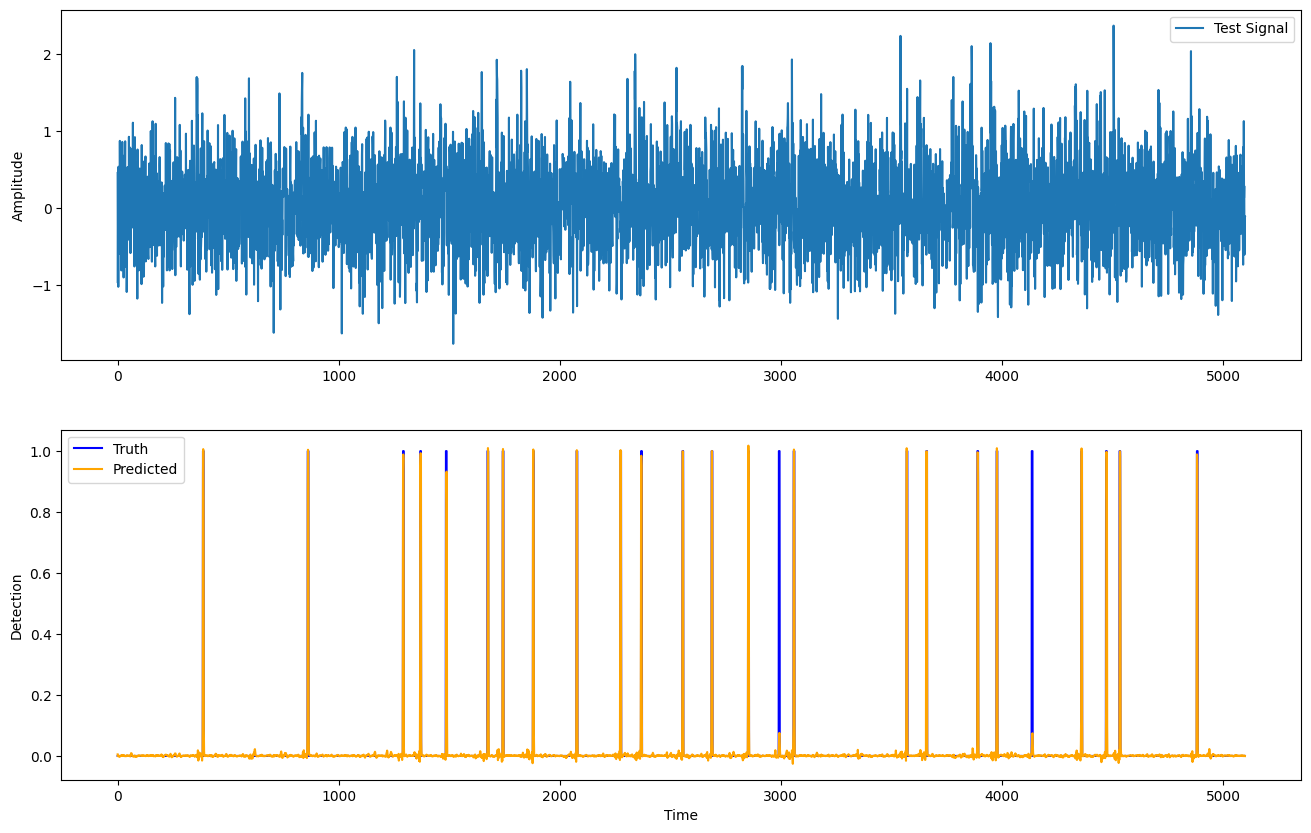

In [6]:
# Plot Results
plt.figure(figsize=(16, 10))
plt.subplot(2, 1, 1)
plt.plot(testX.squeeze().numpy(), label='Test Signal')
plt.ylabel('Amplitude')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(testy.squeeze().numpy(), label='Truth', color='blue')
plt.plot(predictions, label='Predicted', color='orange', linestyle='-')
plt.xlabel('Time')
plt.ylabel('Detection')
plt.legend()
plt.show()

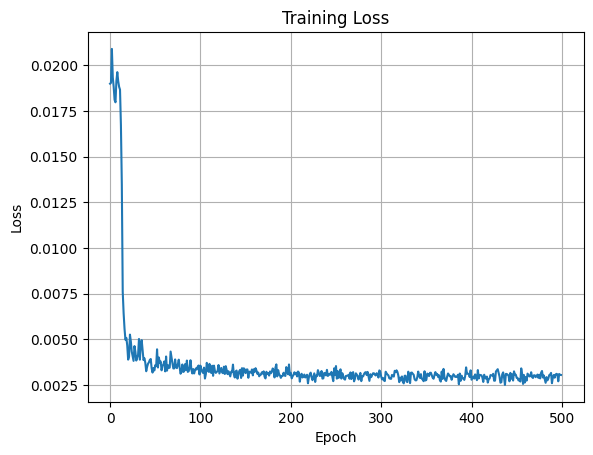

In [7]:
plt.plot(loss_list)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()